# Reusable Template: Exploratory Stats + Resampling Project

A generic starting point for any project that needs to: load data → classify it →
describe it → check normality → resample (bootstrap/permutation test) →
transform if needed → report. Replace the `# CONFIG` values and the `load_data()`
function body, then run top to bottom.

**How to reuse this template:**
1. Duplicate this notebook and rename it for your project.
2. Fill in `CONFIG` and `load_data()`.
3. Delete any module you don't need (e.g., skip Section 5 if you're not comparing groups).
4. Everything downstream reads from the `df` / `group_a` / `group_b` variables set in Section 1.


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 4.5)

# ============== CONFIG — edit this block for your project ==============
CONFIG = {
    'numeric_column': 'income',      # the ratio/interval column you care about
    'group_column': 'type',          # categorical column defining groups to compare
    'group_a_label': 'professional', # first group value
    'group_b_label': 'blue-collar',  # second group value
    'n_bootstrap': 10000,
    'n_permutation': 10000,
    'alpha': 0.05,                   # significance level
}
# =========================================================================


## 1. Load data
Replace the body of `load_data()` with your own source: `pd.read_csv(...)`,
a database query, an API call, etc. The rest of the template only assumes `df`
is a `pandas.DataFrame` containing `CONFIG['numeric_column']` and
`CONFIG['group_column']`.


In [2]:
def load_data():
    '''TODO: replace with your real data source.'''
    import statsmodels.api as sm
    df = sm.datasets.get_rdataset("Duncan", "carData").data
    df.loc[df['type'] == 'prof', 'type'] = 'professional'
    df.loc[df['type'] == 'wc', 'type'] = 'white-collar'
    df.loc[df['type'] == 'bc', 'type'] = 'blue-collar'
    return df

df = load_data()
print(df.shape)
df.head()


(45, 4)


,type,income,education,prestige
rownames,,,,
accountant,professional,62,86,82
pilot,professional,72,76,83
architect,professional,75,92,90
author,professional,55,90,76
chemist,professional,64,86,90


## 2. Classify your variable(s)
Fill in the table for your own dataset before proceeding — this determines which
statistics are even valid to compute.

| Column | Type (nominal/ordinal/interval/ratio) | Notes |
|---|---|---|
| `CONFIG['numeric_column']` | | |
| `CONFIG['group_column']` | | |


## 3. Describe the distribution(s)


--- All income ---
  n              : 45
  mean           : 41.867
  median         : 42.000
  std (ddof=1)   : 24.435
  min            : 7
  Q1             : 21.000
  Q3             : 64.000
  IQR            : 43.000
  max            : 81
  skew           : 0.110
  kurtosis       : -1.364


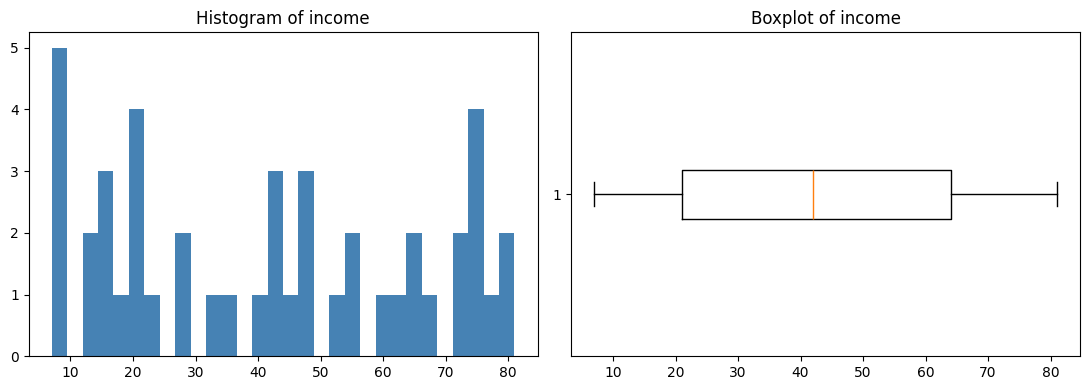

In [3]:
col = CONFIG['numeric_column']
grp = CONFIG['group_column']

def describe(series, label=''):
    s = pd.Series(series).dropna()
    q1, med, q3 = np.quantile(s, [0.25, 0.5, 0.75])
    iqr = q3 - q1
    summary = {
        'n': len(s), 'mean': s.mean(), 'median': med, 'std (ddof=1)': s.std(ddof=1),
        'min': s.min(), 'Q1': q1, 'Q3': q3, 'IQR': iqr, 'max': s.max(),
        'skew': stats.skew(s), 'kurtosis': stats.kurtosis(s),
    }
    print(f"--- {label or series.name} ---")
    for k, v in summary.items():
        print(f"  {k:15s}: {v:.3f}" if isinstance(v, float) else f"  {k:15s}: {v}")
    return summary

overall_summary = describe(df[col], label=f'All {col}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df[col].dropna(), bins=30, color='steelblue')
ax[0].set_title(f'Histogram of {col}')
ax[1].boxplot(df[col].dropna(), vert=False)
ax[1].set_title(f'Boxplot of {col}')
plt.tight_layout(); plt.show()


In [4]:
# Outlier check via Tukey fences
q1, q3 = np.quantile(df[col].dropna(), [0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df[col] < lo) | (df[col] > hi)]
print(f"Tukey fences: [{lo:.2f}, {hi:.2f}]  |  {len(outliers)} potential outlier row(s)")
outliers


Tukey fences: [-43.50, 128.50]  |  0 potential outlier row(s)


,type,income,education,prestige
rownames,,,,


## 4. Normality check


In [5]:
sample_for_test = df[col].dropna()
if len(sample_for_test) > 5000:
    sample_for_test = sample_for_test.sample(5000, random_state=0)  # Shapiro is unreliable/slow for huge n

stat, p_shapiro = stats.shapiro(sample_for_test)
print(f"Shapiro-Wilk p-value: {p_shapiro:.4f}")
if p_shapiro < CONFIG['alpha']:
    print("-> Reject normality. Consider a transformation (Section 6) before parametric tests.")
else:
    print("-> Fail to reject normality. Parametric tests (t-test, Pearson r) are reasonable.")


Shapiro-Wilk p-value: 0.0049
-> Reject normality. Consider a transformation (Section 6) before parametric tests.


## 5. Compare two groups (bootstrap + permutation test)
Skip/delete this section if your project isn't a two-group comparison.


professional: n=18   blue-collar: n=21


professional mean 95% CI: (np.float64(52.39), np.float64(67.11))
blue-collar mean 95% CI: (np.float64(17.05), np.float64(32.0))
CIs overlap: False  (evidence of a difference)


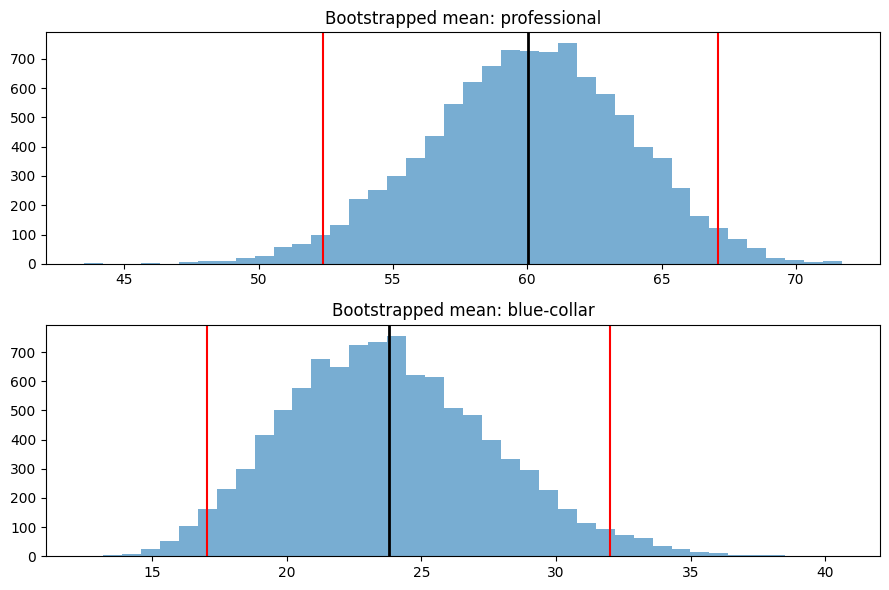

In [6]:
group_a = df.loc[df[grp] == CONFIG['group_a_label'], col].dropna().values
group_b = df.loc[df[grp] == CONFIG['group_b_label'], col].dropna().values
print(f"{CONFIG['group_a_label']}: n={len(group_a)}   {CONFIG['group_b_label']}: n={len(group_b)}")

def bootstrap_stat(sample, stat_fn=np.mean, n_replicas=10000, frac=1.0, replace=True, seed=None):
    rng = np.random.default_rng(seed)
    sample = np.asarray(sample)
    n = max(1, int(len(sample) * frac))
    return np.array([stat_fn(rng.choice(sample, size=n, replace=replace)) for _ in range(n_replicas)])

def bootstrap_ci(boot_dist, alpha=0.05):
    p = alpha * 100
    return np.percentile(boot_dist, p/2), np.percentile(boot_dist, 100 - p/2)

boot_a = bootstrap_stat(group_a, n_replicas=CONFIG['n_bootstrap'], seed=1)
boot_b = bootstrap_stat(group_b, n_replicas=CONFIG['n_bootstrap'], seed=2)
ci_a, ci_b = bootstrap_ci(boot_a, CONFIG['alpha']), bootstrap_ci(boot_b, CONFIG['alpha'])

print(f"{CONFIG['group_a_label']} mean 95% CI: {tuple(round(v,2) for v in ci_a)}")
print(f"{CONFIG['group_b_label']} mean 95% CI: {tuple(round(v,2) for v in ci_b)}")
overlap = not (ci_a[1] < ci_b[0] or ci_b[1] < ci_a[0])
print(f"CIs overlap: {overlap}  ({'no strong evidence of a difference' if overlap else 'evidence of a difference'})")

fig, ax = plt.subplots(2, 1, figsize=(9, 6))
for a, boot, label, ci_ in zip(ax, [boot_a, boot_b],
                                [CONFIG['group_a_label'], CONFIG['group_b_label']], [ci_a, ci_b]):
    a.hist(boot, bins=40, alpha=0.6)
    a.axvline(boot.mean(), color='black', lw=2)
    a.axvline(ci_[0], color='red'); a.axvline(ci_[1], color='red')
    a.set_title(f'Bootstrapped mean: {label}')
plt.tight_layout(); plt.show()


Observed difference in means: 36.294
Permutation p-value (two-sided): 0.0000
-> Statistically significant at alpha=0.05


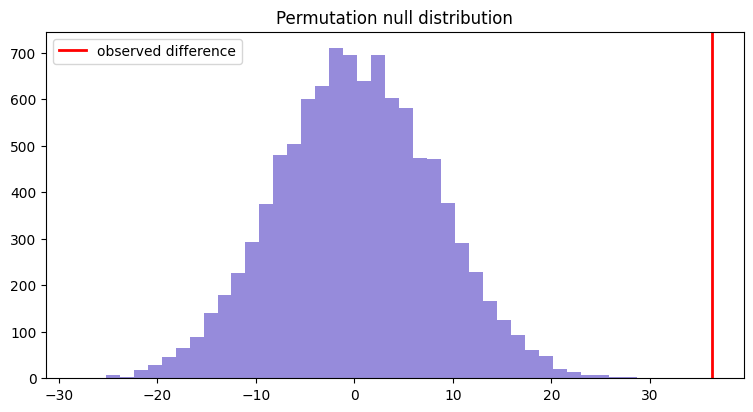

In [7]:
def permutation_test(A, B, n_iter=10000, seed=None, alternative='two-sided'):
    rng = np.random.default_rng(seed)
    A, B = np.asarray(A, dtype=float), np.asarray(B, dtype=float)
    observed = A.mean() - B.mean()
    pooled = np.concatenate([A, B]); n_a = len(A)
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        rng.shuffle(pooled)
        diffs[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    if alternative == 'greater':
        p = np.mean(diffs >= observed)
    elif alternative == 'less':
        p = np.mean(diffs <= observed)
    else:
        p = np.mean(np.abs(diffs) >= abs(observed))
    return p, observed, diffs

p_val, observed_diff, null_diffs = permutation_test(
    group_a, group_b, n_iter=CONFIG['n_permutation'], seed=42, alternative='two-sided')

print(f"Observed difference in means: {observed_diff:.3f}")
print(f"Permutation p-value (two-sided): {p_val:.4f}")
print("-> Statistically significant at alpha={}".format(CONFIG['alpha'])
      if p_val < CONFIG['alpha'] else "-> Not statistically significant at alpha={}".format(CONFIG['alpha']))

plt.hist(null_diffs, bins=40, color='slateblue', alpha=0.7)
plt.axvline(observed_diff, color='red', lw=2, label='observed difference')
plt.legend(); plt.title('Permutation null distribution'); plt.show()


## 6. Transform if needed
Only run this if Section 4 rejected normality and your downstream analysis
needs (approximately) normal data.


Box-Cox lambda: 0.549
Original skew: 0.110
log      skew: -0.626
sqrt     skew: -0.223
cbrt     skew: -0.349
log1p    skew: -0.589
boxcox   skew: -0.187


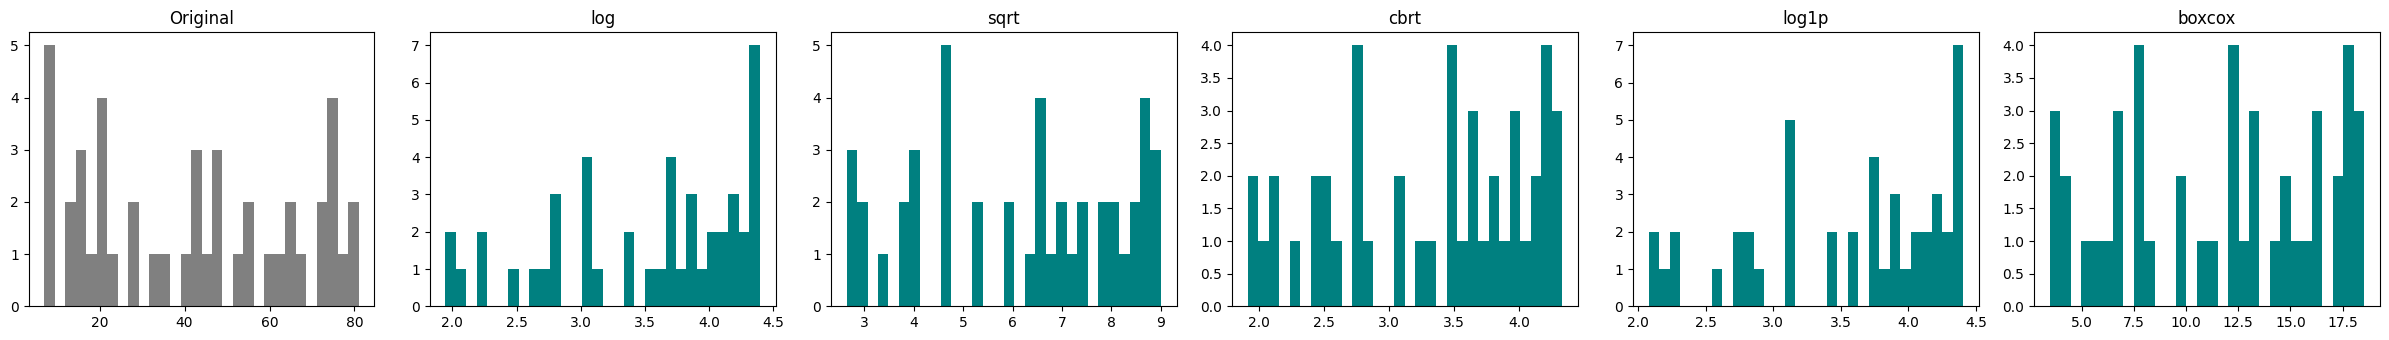

In [8]:
raw = df[col].dropna()
raw_positive = raw[raw > 0]  # log/boxcox need strictly positive values

candidates = {
    'log': np.log(raw_positive),
    'sqrt': np.sqrt(raw[raw >= 0]),
    'cbrt': np.cbrt(raw),
    'log1p': np.log1p(raw[raw > -1]),
}
try:
    bc, best_lambda = stats.boxcox(raw_positive)
    candidates['boxcox'] = pd.Series(bc)
    print(f"Box-Cox lambda: {best_lambda:.3f}")
except Exception as e:
    print("Box-Cox skipped:", e)

print(f"Original skew: {stats.skew(raw):.3f}")
for name, arr in candidates.items():
    print(f"{name:8s} skew: {stats.skew(arr):.3f}")

fig, axes = plt.subplots(1, len(candidates)+1, figsize=(4*(len(candidates)+1), 3.5))
axes[0].hist(raw, bins=30, color='gray'); axes[0].set_title('Original')
for ax, (name, arr) in zip(axes[1:], candidates.items()):
    ax.hist(arr, bins=30, color='teal'); ax.set_title(name)
plt.tight_layout(); plt.show()


## 7. Report
Fill this in for your actual project:

- **Data & sample size:**
- **Data type(s) and why it matters here:**
- **Key descriptive statistics:**
- **Normality / skew findings and any transformation applied:**
- **Group comparison result (bootstrap CI + permutation p-value) and interpretation:**
- **Caveats / limitations (sample size, missing stratification, simulation vs. real data, etc.):**
